# Preprocessing Pipeline
**Nama Proyek:** Pothole Detection System

Notebook ini mencakup:
1. Data Cleaning & Handling Missing Values
2. Data Manipulation / Feature Transformation
3. Insight & Dokumentasi Preprocessing

In [1]:
import os
import shutil
import csv
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torchvision import transforms

ROOT      = Path("../").resolve()
DATA_DIR  = ROOT / "data" / "raw" / "images"
PROC_DIR  = ROOT / "data" / "processed"   # hasil resize+RGB
SPLIT_DIR = ROOT / "data" / "split"       # manifest CSV
CLASSES   = ["normal", "potholes"]
IMG_SIZE  = (224, 224)
SEED      = 42
random.seed(SEED)

print(f"Root      : {ROOT}")
print(f"Raw data  : {DATA_DIR}")
print(f"Processed : {PROC_DIR}")
print(f"Split dir : {SPLIT_DIR}")

Root      : M:\final_dbb
Raw data  : M:\final_dbb\data\raw\images
Processed : M:\final_dbb\data\processed
Split dir : M:\final_dbb\data\split


---
## Data Cleaning & Handling Missing Values

Proses cleaning pada image dataset:
- Deteksi file corrupt / tidak bisa dibuka
- Deteksi gambar non-RGB (grayscale, RGBA, dll)
- Deteksi gambar berukuran sangat kecil (< 32×32 px)
- Rekap hasil cleaning

In [2]:
valid_records = []
issues = []

MIN_SIZE = 32

for cls in CLASSES:
    for fpath in tqdm(sorted((DATA_DIR / cls).glob("*.jpg")), desc=f"Scanning {cls}"):
        reason = None
        try:
            with Image.open(fpath) as img:
                img.verify()
            with Image.open(fpath) as img:
                w, h = img.size
                mode = img.mode
            if w < MIN_SIZE or h < MIN_SIZE:
                reason = f"terlalu kecil ({w}x{h})"
        except Exception as e:
            reason = f"corrupt: {e}"
            w, h, mode = None, None, None

        if reason:
            issues.append({"filename": fpath.name, "class": cls, "reason": reason})
        else:
            valid_records.append({
                "filename": fpath.name, "path": fpath,
                "class": cls, "width": w, "height": h, "mode": mode
            })

df = pd.DataFrame(valid_records)

print(f"\n{'='*45}")
print(f"  DATA CLEANING REPORT")
print(f"{'='*45}")
print(f"  Total file di-scan : {len(valid_records) + len(issues)}")
print(f"  File valid         : {len(valid_records)}")
print(f"  File bermasalah    : {len(issues)}")
if issues:
    print("\n  Detail file bermasalah:")
    print(pd.DataFrame(issues).to_string(index=False))
else:
    print("  ✓ Tidak ada file bermasalah.")
print(f"{'='*45}")

Scanning potholes: 100%|██████████| 329/329 [00:00<00:00, 6356.94it/s]


  DATA CLEANING REPORT
  Total file di-scan : 681
  File valid         : 681
  File bermasalah    : 0
  ✓ Tidak ada file bermasalah.


In [3]:
non_rgb = df[df["mode"] != "RGB"]

if len(non_rgb) > 0:
    print(f"⚠  {len(non_rgb)} gambar non-RGB ditemukan:")
    print(non_rgb[["class", "filename", "mode"]].to_string(index=False))
    print("\n→ Semua akan di-convert ke RGB otomatis saat load (Image.open().convert('RGB'))")
else:
    print("✓ Semua gambar sudah RGB — tidak perlu konversi.")

print(f"\nColor mode distribution:")
print(df["mode"].value_counts().to_string())

⚠  2 gambar non-RGB ditemukan:
   class filename mode
  normal  226.jpg    P
potholes  312.jpg RGBA

→ Semua akan di-convert ke RGB otomatis saat load (Image.open().convert('RGB'))

Color mode distribution:
mode
RGB     679
P         1
RGBA      1


---
## Data Manipulation / Feature Transformation

### Train / Val / Test Split (Stratified 70/15/15)

Split     Total    normal    potholes
--------------------------------------
train       476       246         230
val         102        53          49
test        103        53          50


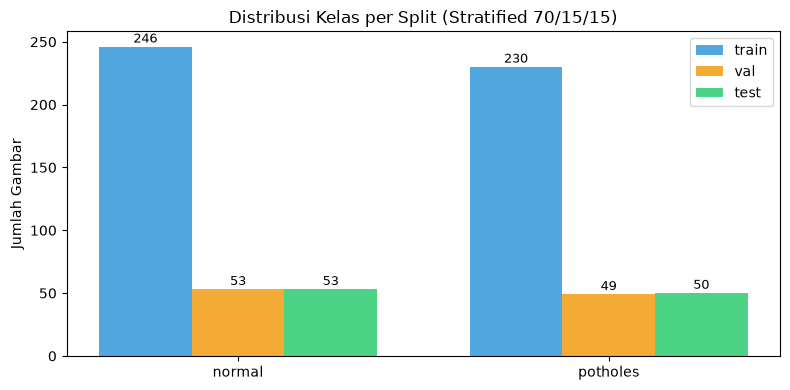

In [4]:
paths  = df["path"].tolist()
labels = df["class"].tolist()

# Split test dulu
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    paths, labels, test_size=0.15, stratify=labels, random_state=SEED
)
# Split val dari train
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=0.15 / 0.85, stratify=train_val_labels, random_state=SEED
)

splits = {
    "train": list(zip(train_paths, train_labels)),
    "val"  : list(zip(val_paths,   val_labels)),
    "test" : list(zip(test_paths,  test_labels)),
}

print(f"{'Split':<8} {'Total':>6}  {'normal':>8}  {'potholes':>10}")
print("-" * 38)
for split_name, data in splits.items():
    n = sum(1 for _, l in data if l == "normal")
    p = sum(1 for _, l in data if l == "potholes")
    print(f"{split_name:<8} {len(data):>6}  {n:>8}  {p:>10}")

# Visualisasi distribusi split
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(CLASSES))
width = 0.25
split_colors = {"train": "#3498db", "val": "#f39c12", "test": "#2ecc71"}

for i, (split_name, data) in enumerate(splits.items()):
    counts = [sum(1 for _, l in data if l == cls) for cls in CLASSES]
    bars = ax.bar(x + i * width, counts, width, label=split_name, color=split_colors[split_name], alpha=0.85)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(count), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASSES)
ax.set_title("Distribusi Kelas per Split (Stratified 70/15/15)")
ax.set_ylabel("Jumlah Gambar")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "preproc_split_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

In [5]:
# Resize + convert RGB -> data/processed/
print(f"Menyimpan gambar 224×224 RGB ke {PROC_DIR} ...")

for split_name, data in splits.items():
    for fpath, label in tqdm(data, desc=split_name):
        dest_dir = PROC_DIR / split_name / label
        dest_dir.mkdir(parents=True, exist_ok=True)
        dest_path = dest_dir / fpath.name

        if not dest_path.exists():
            img = Image.open(fpath).convert("RGB").resize(IMG_SIZE, Image.LANCZOS)
            img.save(dest_path, "JPEG", quality=95)

# Simpan manifest CSV
SPLIT_DIR.mkdir(parents=True, exist_ok=True)
manifest_path = SPLIT_DIR / "manifest.csv"
with open(manifest_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["split", "label", "filename"])
    writer.writeheader()
    for split_name, data in splits.items():
        for fpath, label in data:
            writer.writerow({"split": split_name, "label": label, "filename": fpath.name})

print(f"\n✓ Gambar ter-resize tersimpan di : {PROC_DIR}")
print(f"✓ Manifest CSV                   : {manifest_path}")

# Verifikasi jumlah file
print("\nVerifikasi:")
for split_name in splits:
    for cls in CLASSES:
        count = len(list((PROC_DIR / split_name / cls).glob("*.jpg")))
        print(f"  {split_name}/{cls}: {count} file")

Menyimpan gambar 224×224 RGB ke M:\final_dbb\data\processed ...


test: 100%|██████████| 103/103 [00:00<00:00, 11005.59it/s]


✓ Gambar ter-resize tersimpan di : M:\final_dbb\data\processed
✓ Manifest CSV                   : M:\final_dbb\data\split\manifest.csv

Verifikasi:
  train/normal: 246 file
  train/potholes: 230 file
  val/normal: 53 file
  val/potholes: 49 file
  test/normal: 53 file
  test/potholes: 50 file


### Feature Transformation — Augmentasi & Normalisasi

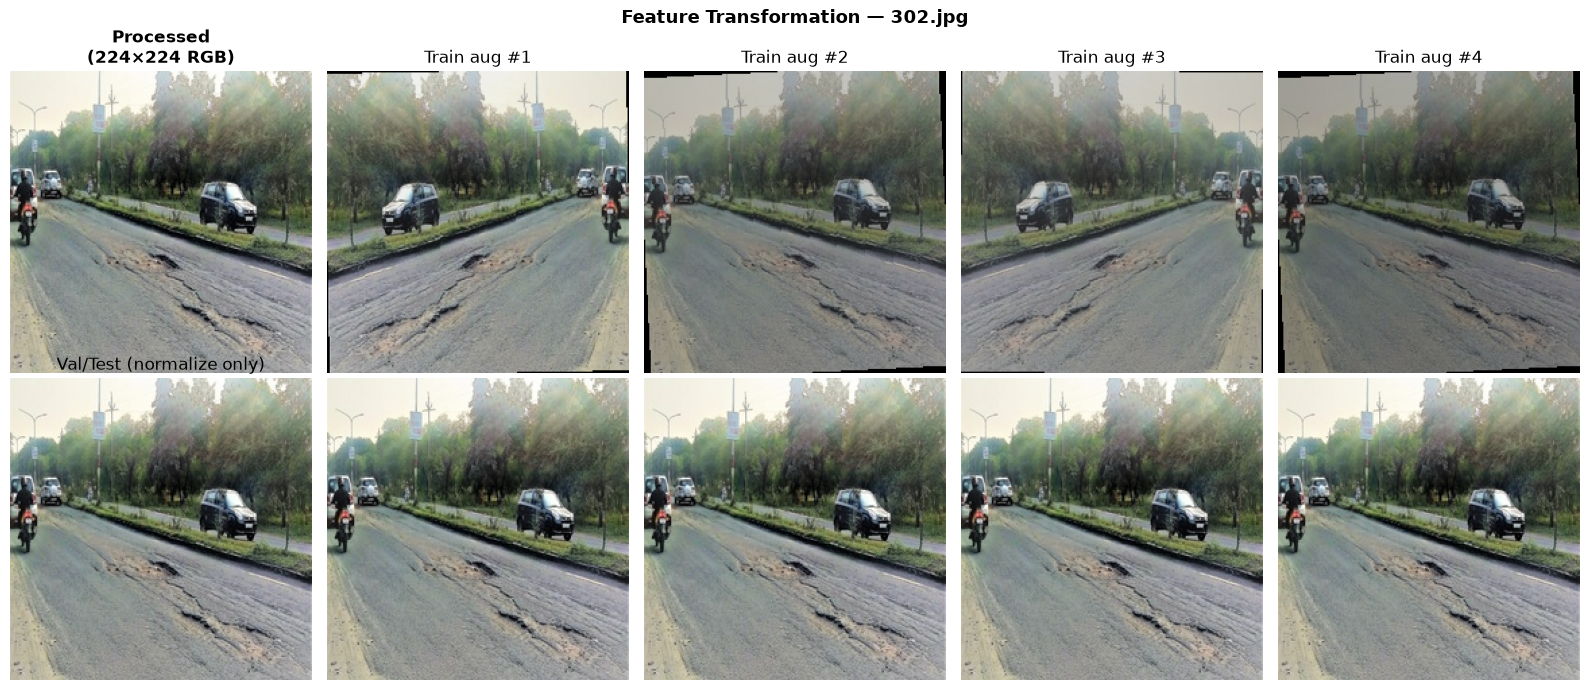

Disimpan ke disk : Resize 224×224 + Convert RGB (JPEG quality=95)
Real-time train  : HFlip, VFlip, ColorJitter, Rotation, Normalize
Real-time val    : Normalize only


In [6]:
# Transform train
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Transform val/test
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Visualisasi efek augmentasi
sample_path = random.choice(list((PROC_DIR / "train" / "potholes").glob("*.jpg")))
original = Image.open(sample_path).convert("RGB")

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denorm(tensor):
    return (tensor * std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle(f"Feature Transformation — {sample_path.name}", fontsize=13, fontweight="bold")

axes[0,0].imshow(original)
axes[0,0].set_title("Processed\n(224×224 RGB)", fontweight="bold")
axes[0,0].axis("off")
for i in range(1, 5):
    axes[0,i].imshow(denorm(transform_train(original)))
    axes[0,i].set_title(f"Train aug #{i}")
    axes[0,i].axis("off")

val_img = denorm(transform_val(original))
for i in range(5):
    axes[1,i].imshow(val_img)
    axes[1,i].set_title("Val/Test (normalize only)" if i == 0 else "")
    axes[1,i].axis("off")

axes[0,0].set_ylabel("TRAIN", fontsize=11, fontweight="bold", rotation=90)
axes[1,0].set_ylabel("VAL/TEST", fontsize=11, fontweight="bold", rotation=90)

plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "preproc_augmentation.png", dpi=120, bbox_inches="tight")
plt.show()

print("Disimpan ke disk : Resize 224×224 + Convert RGB (JPEG quality=95)")
print("Real-time train  : HFlip, VFlip, ColorJitter, Rotation, Normalize")
print("Real-time val    : Normalize only")

---
## Insight & Dokumentasi Preprocessing

In [7]:
total = len(df)
class_counts = df["class"].value_counts().to_dict()

print("=" * 60)
print("     PREPROCESSING REPORT — Pothole Detection")
print("=" * 60)

print(f"\n[DATA CLEANING]")
print(f"  Total file di-scan  : {total + len(issues)}")
print(f"  File valid          : {total}")
print(f"  File dihapus/skip   : {len(issues)}")
print(f"  Non-RGB di-convert  : {'Ya (otomatis)' if len(non_rgb) > 0 else 'Tidak ada'}")

print(f"\n[SPLIT RESULT]")
for split_name, data in splits.items():
    n = sum(1 for _, l in data if l == "normal")
    p = sum(1 for _, l in data if l == "potholes")
    print(f"  {split_name:<6}: {len(data):3d} gambar  (normal={n}, potholes={p})")

print(f"\n[FEATURE TRANSFORMATION]")
print(f"  Target size     : 224 × 224 px")
print(f"  Train augment   : RandomCrop, HFlip, VFlip, ColorJitter, Rotation")
print(f"  Val/Test        : Resize + Normalize only")
print(f"  Normalisasi     : ImageNet mean/std")
print(f"  Class weight    : Akan diterapkan pada loss function")

print(f"\n[INSIGHTS]")
ratio = max(class_counts.values()) / min(class_counts.values())
print(f"  1. Dataset bersih — {len(issues)} file bermasalah, tidak signifikan.")
print(f"  2. Class imbalance sangat ringan (ratio {ratio:.2f}:1).")
print(f"     → Ditangani dengan class_weight pada CrossEntropyLoss,")
print(f"       bukan oversampling/SMOTE karena imbalance di bawah 1.5:1.")
print(f"  3. Dimensi bervariasi → resize wajib sebelum masuk model.")
print(f"  4. ColorJitter penting karena foto jalan diambil dalam berbagai")
print(f"     kondisi cahaya — membantu model lebih robust.")
print(f"  5. VerticalFlip sengaja diset p=0.2 (rendah) karena foto jalan")
print(f"     memiliki orientasi atas-bawah yang bermakna.")
print("=" * 60)

     PREPROCESSING REPORT — Pothole Detection

[DATA CLEANING]
  Total file di-scan  : 681
  File valid          : 681
  File dihapus/skip   : 0
  Non-RGB di-convert  : Ya (otomatis)

[SPLIT RESULT]
  train : 476 gambar  (normal=246, potholes=230)
  val   : 102 gambar  (normal=53, potholes=49)
  test  : 103 gambar  (normal=53, potholes=50)

[FEATURE TRANSFORMATION]
  Target size     : 224 × 224 px
  Train augment   : RandomCrop, HFlip, VFlip, ColorJitter, Rotation
  Val/Test        : Resize + Normalize only
  Normalisasi     : ImageNet mean/std
  Class weight    : Akan diterapkan pada loss function

[INSIGHTS]
  1. Dataset bersih — 0 file bermasalah, tidak signifikan.
  2. Class imbalance sangat ringan (ratio 1.07:1).
     → Ditangani dengan class_weight pada CrossEntropyLoss,
       bukan oversampling/SMOTE karena imbalance di bawah 1.5:1.
  3. Dimensi bervariasi → resize wajib sebelum masuk model.
  4. ColorJitter penting karena foto jalan diambil dalam berbagai
     kondisi cahaya —

Manifest shape: (681, 3)
label  normal  potholes
split                  
test       53        50
train     246       230
val        53        49


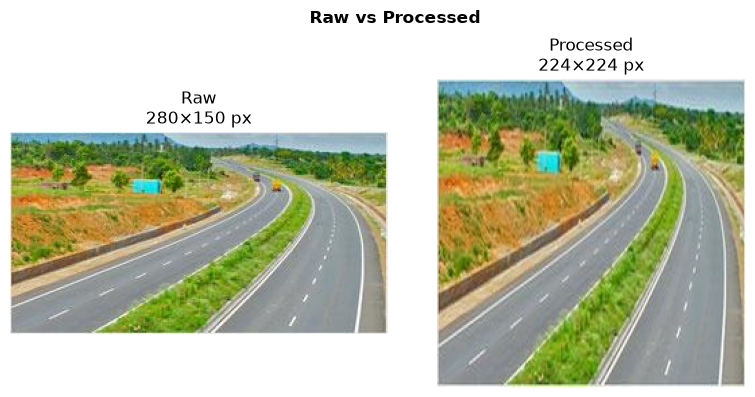

In [8]:
# Preview manifest CSV
manifest_df = pd.read_csv(SPLIT_DIR / "manifest.csv")
print(f"Manifest shape: {manifest_df.shape}")
print(manifest_df.groupby(["split", "label"]).size().unstack(fill_value=0))

# Cek sample gambar hasil processed vs raw
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
raw_sample = Image.open(df.iloc[0]["path"])
proc_sample = Image.open(PROC_DIR / "train" / df.iloc[0]["class"] / df.iloc[0]["filename"])

axes[0].imshow(raw_sample)
axes[0].set_title(f"Raw\n{raw_sample.size[0]}×{raw_sample.size[1]} px")
axes[0].axis("off")

axes[1].imshow(proc_sample)
axes[1].set_title(f"Processed\n{proc_sample.size[0]}×{proc_sample.size[1]} px")
axes[1].axis("off")

plt.suptitle("Raw vs Processed", fontweight="bold")
plt.tight_layout()
plt.show()